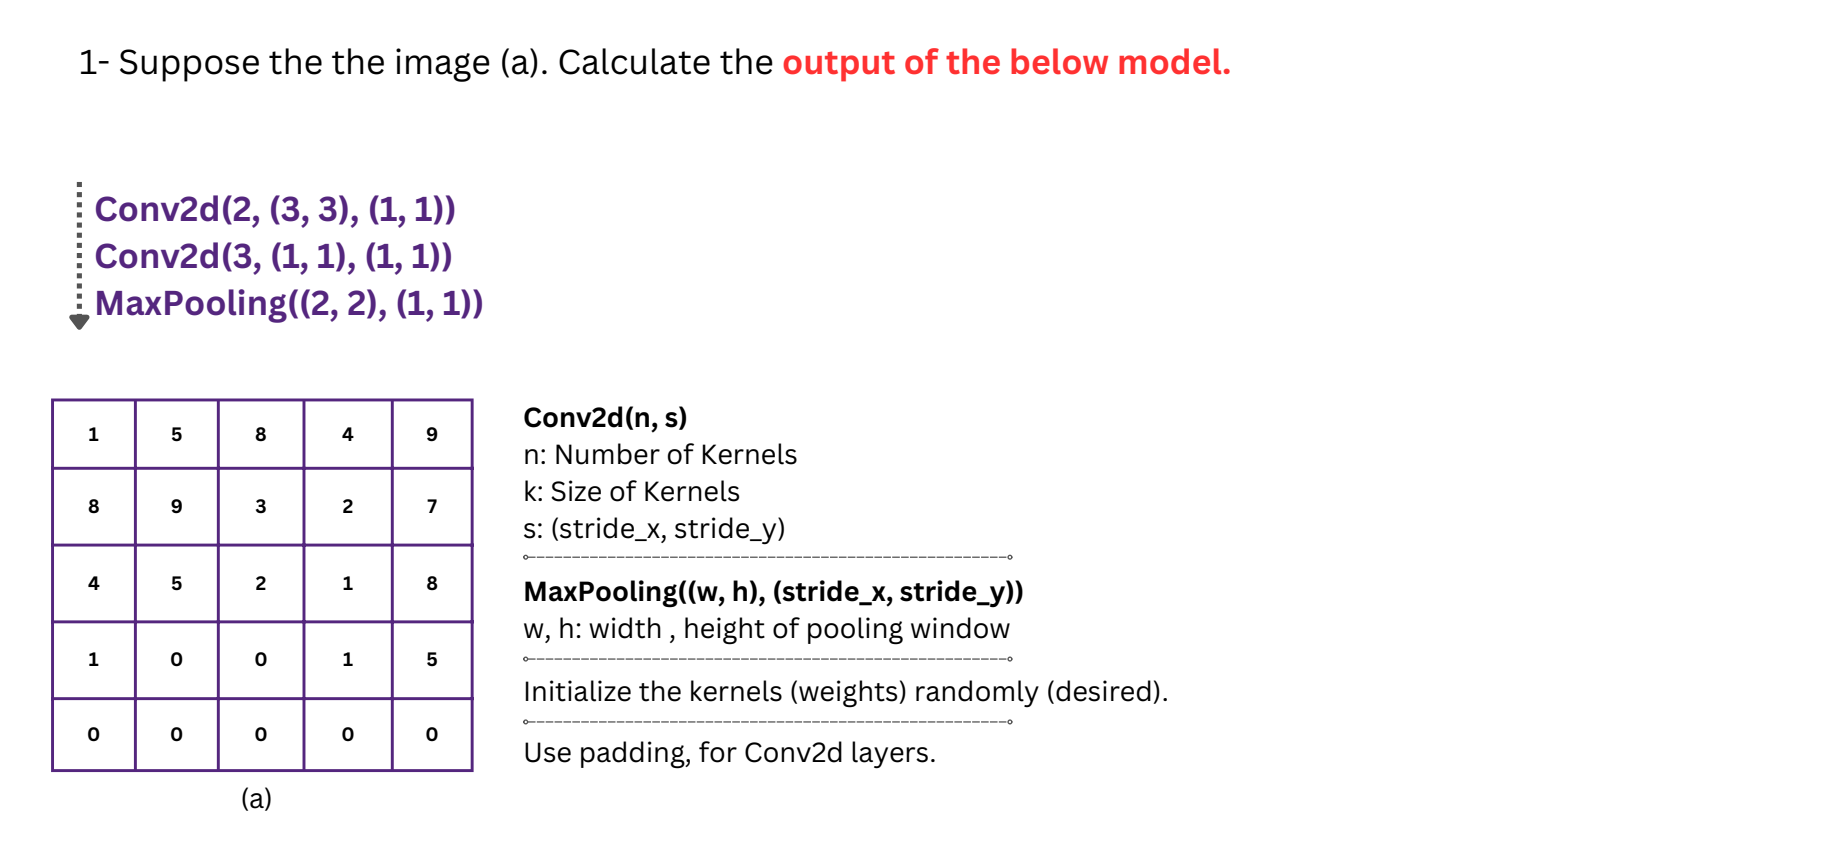

I'll work through this CNN architecture question step by step, tracking the spatial dimensions through each layer (since exact output values depend on randomly initialized kernels, I'll focus on the dimension calculations, which is what's actually being tested here).

## Setup

Input image (a) is a **5×5** matrix:
```
1  5  8  4  9
8  9  3  2  7
4  5  2  1  8
1  0  0  1  5
0  0  0  0  0
```

The general formula for spatial output size (per dimension) is:

$$
\text{out} = \left\lfloor \frac{\text{in} + 2p - k}{s} \right\rfloor + 1
$$

Since "use padding for Conv2d layers" is specified, I'll assume **same padding** (output size = input size) for the conv layers, which is the standard interpretation when padding is requested without a specific value — this also makes the architecture work out cleanly. MaxPooling uses **no padding** (only Conv2d layers are told to use padding).

### Layer 1: Conv2d(2, (3,3), (1,1)) — 2 kernels, 3×3, stride 1, padding (same)

- Padding needed: $p = \frac{k-1}{2} = 1$
- Output size: $\frac{5 + 2(1) - 3}{1} + 1 = 5$
- **Output shape: 5 × 5 × 2** (2 feature maps, since 2 kernels)

### Layer 2: Conv2d(3, (1,1), (1,1)) — 3 kernels, 1×1, stride 1, padding (same)

- 1×1 kernel needs no padding to preserve size ($p=0$)
- Output size: $\frac{5 + 0 - 1}{1} + 1 = 5$
- **Output shape: 5 × 5 × 3** (3 feature maps, since 3 kernels)

### Layer 3: MaxPooling((2,2), (1,1)) — 2×2 window, stride 1, no padding

- Output size: $\frac{5 - 2}{1} + 1 = 4$
- **Output shape: 4 × 4 × 3**

### Final Answer

$$
\boxed{\text{Output shape} = 4 \times 4 \times 3}
$$

**Dimension trace:**

| Layer | Operation | Output Shape |
|---|---|---|
| Input | — | 5×5×1 |
| Conv2d(2,(3,3),(1,1)) | same padding | 5×5×2 |
| Conv2d(3,(1,1),(1,1)) | same padding | 5×5×3 |
| MaxPooling((2,2),(1,1)) | valid (no pad) | 4×4×3 |



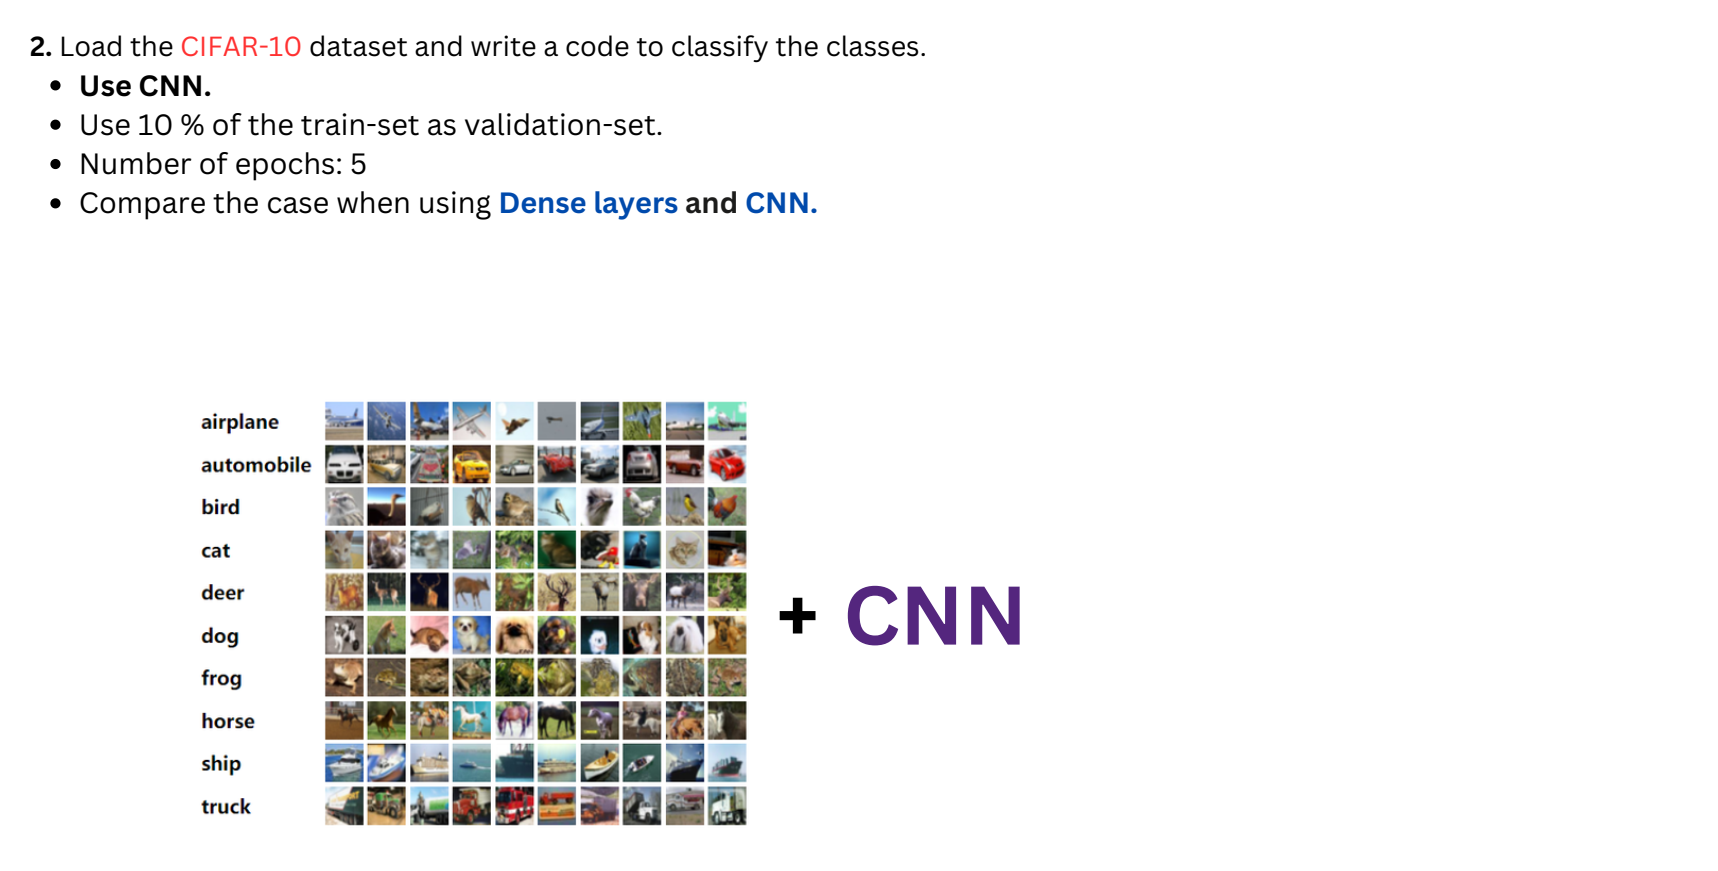

Full train set: (50000, 32, 32, 3), (50000, 1)
Test set:       (10000, 32, 32, 3), (10000, 1)
Train: 45000 samples
Val:   5000 samples
Test:  10000 samples

Training Dense (MLP) model


Model: "Dense_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
704/704 - 40s - 57ms/step - accuracy: 0.4266 - loss: 1.5685 - val_accuracy: 0.5672 - val_loss: 1.1816
Epoch 2/5
704/704 - 49s - 70ms/step - accuracy: 0.5844 - loss: 1.1620 - val_accuracy: 0.6430 - val_loss: 0.9714
Epoch 3/5
704/704 - 43s - 62ms/step - accuracy: 0.6459 - loss: 1.0013 - val_accuracy: 0.6608 - val_loss: 0.9448
Epoch 4/5
704/704 - 39s - 56ms/step - accuracy: 0.6819 - loss: 0.8972 - val_accuracy: 0.7006 - val_loss: 0.8376
Epoch 5/5
704/704 - 43s - 60ms/step - accuracy: 0.7098 - loss: 0.8255 - val_accuracy: 0.7362 - val_loss: 0.7481

FINAL COMPARISON (Test Set)
Model          Test Loss      Test Accuracy  # Params       
Dense MLP      1.7897         0.3592         1,707,274      
CNN            0.7691         0.7299         1,116,970      


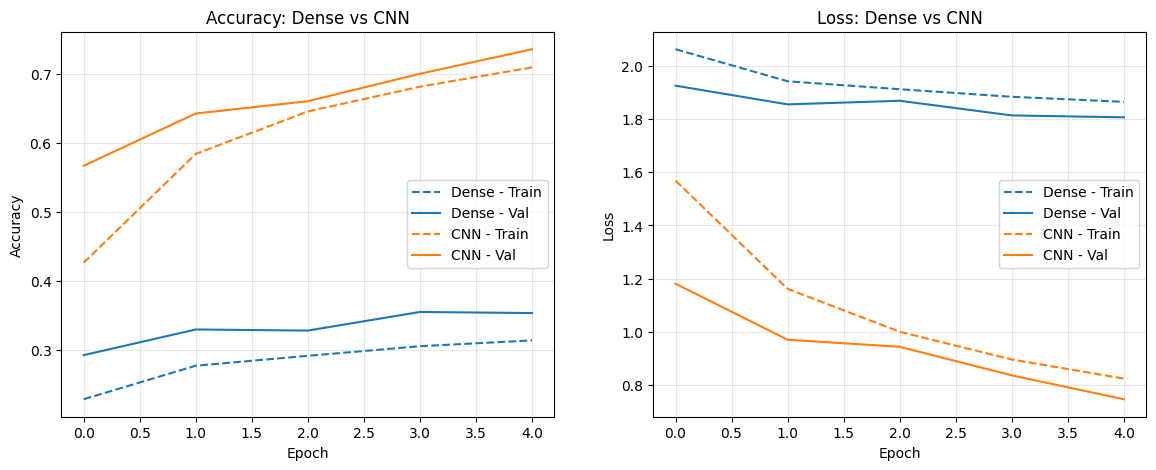

In [1]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 0. Reproducibility
# ----------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 5
VAL_SPLIT = 0.10
BATCH_SIZE = 64
NUM_CLASSES = 10

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ----------------------------------------------------------------------
# 1. Load CIFAR-10
# ----------------------------------------------------------------------
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Full train set: {x_train_full.shape}, {y_train_full.shape}")
print(f"Test set:       {x_test.shape}, {y_test.shape}")

# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels from (N, 1) -> (N,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# ----------------------------------------------------------------------
# 2. Train / Validation split (10% of train set as validation)
# ----------------------------------------------------------------------
num_train = x_train_full.shape[0]
num_val = int(num_train * VAL_SPLIT)

# Shuffle indices before splitting so classes are evenly mixed
rng = np.random.default_rng(SEED)
indices = rng.permutation(num_train)
val_idx, train_idx = indices[:num_val], indices[num_val:]

x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]

print(f"Train: {x_train.shape[0]} samples")
print(f"Val:   {x_val.shape[0]} samples")
print(f"Test:  {x_test.shape[0]} samples")

# ----------------------------------------------------------------------
# 3. Build Model 1: Dense (Fully-Connected) Network
# ----------------------------------------------------------------------
def build_dense_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="Dense_MLP")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# ----------------------------------------------------------------------
# 4. Build Model 2: CNN
# ----------------------------------------------------------------------
def build_cnn_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="CNN")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# ----------------------------------------------------------------------
# 5. Train both models
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("Training Dense (MLP) model")
print("=" * 60)
dense_model = build_dense_model()
dense_model.summary()

dense_history = dense_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

print("\n" + "=" * 60)
print("Training CNN model")
print("=" * 60)
cnn_model = build_cnn_model()
cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

# ----------------------------------------------------------------------
# 6. Evaluate on Test Set
# ----------------------------------------------------------------------
dense_test_loss, dense_test_acc = dense_model.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)

print("\n" + "=" * 60)
print("FINAL COMPARISON (Test Set)")
print("=" * 60)
print(f"{'Model':<15}{'Test Loss':<15}{'Test Accuracy':<15}{'# Params':<15}")
print(f"{'Dense MLP':<15}{dense_test_loss:<15.4f}{dense_test_acc:<15.4f}{dense_model.count_params():<15,}")
print(f"{'CNN':<15}{cnn_test_loss:<15.4f}{cnn_test_acc:<15.4f}{cnn_model.count_params():<15,}")

# ----------------------------------------------------------------------
# 7. Plot Comparison Curves
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(dense_history.history["accuracy"], label="Dense - Train", linestyle="--", color="tab:blue")
axes[0].plot(dense_history.history["val_accuracy"], label="Dense - Val", color="tab:blue")
axes[0].plot(cnn_history.history["accuracy"], label="CNN - Train", linestyle="--", color="tab:orange")
axes[0].plot(cnn_history.history["val_accuracy"], label="CNN - Val", color="tab:orange")
axes[0].set_title("Accuracy: Dense vs CNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(dense_history.history["loss"], label="Dense - Train", linestyle="--", color="tab:blue")
axes[1].plot(dense_history.history["val_loss"], label="Dense - Val", color="tab:blue")
axes[1].plot(cnn_history.history["loss"], label="CNN - Train", linestyle="--", color="tab:orange")
axes[1].plot(cnn_history.history["val_loss"], label="CNN - Val", color="tab:orange")
axes[1].set_title("Loss: Dense vs CNN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()
 

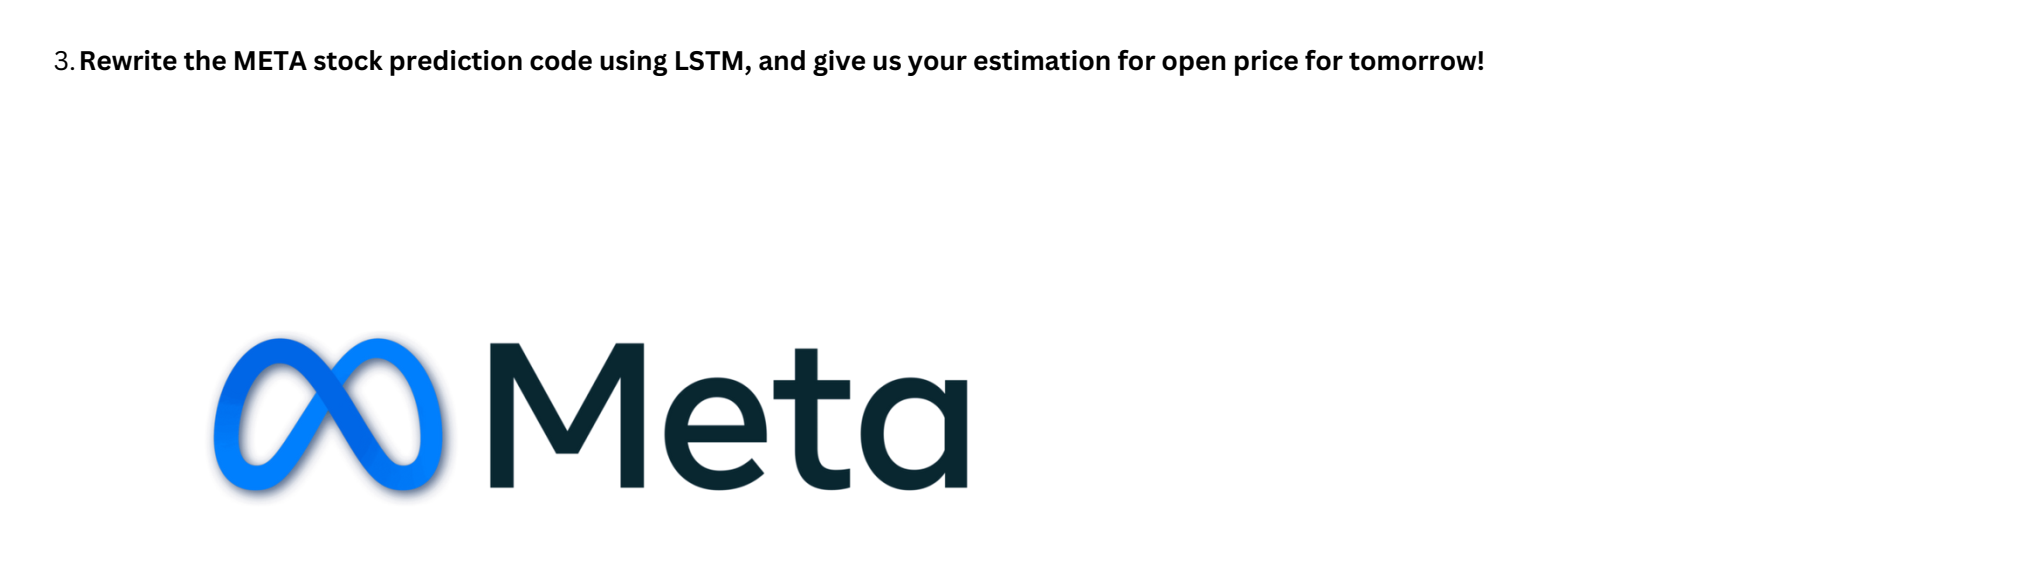

In [2]:
# !pip install yfinance

[*********************100%***********************]  1 of 1 completed

Loaded 1254 real trading days for META.
Price             Open        High         Low       Close    Volume
Ticker            META        META        META        META      META
Date                                                                
2026-06-11  565.306057  571.640152  556.494218  567.903625  17628000
2026-06-12  572.419460  575.536566  560.380630  566.454956  14326400
2026-06-15  579.900024  601.270020  579.299988  593.479980  17653300
2026-06-16  593.650024  605.809998  592.000000  600.210022  11344400
2026-06-17  592.000000  593.809998  566.190002  567.580017  20478300
Train shape: (955, 60, 5), Test shape: (239, 60, 5)



c:\Users\New\.conda\envs\gpu_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0295 - mae: 0.1154 - val_loss: 0.0033 - val_mae: 0.0472
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0049 - mae: 0.0494 - val_loss: 0.0026 - val_mae: 0.0406
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0038 - mae: 0.0426 - val_loss: 0.0030 - val_mae: 0.0445
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0036 - mae: 0.0417 - val_loss: 0.0024 - val_mae: 0.0384
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0033 - mae: 0.0403 - val_loss: 0.0053 - val_mae: 0.0610
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0034 - mae: 0.0399 - val_loss: 0.0035 - val_mae: 0.0481
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0033 - mae: 0.0400 - val_loss: 0.0045 - val_mae: 0.0553
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0024 - mae: 0.0351 - val_loss: 0.0026 - val_mae: 0.0401
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.002

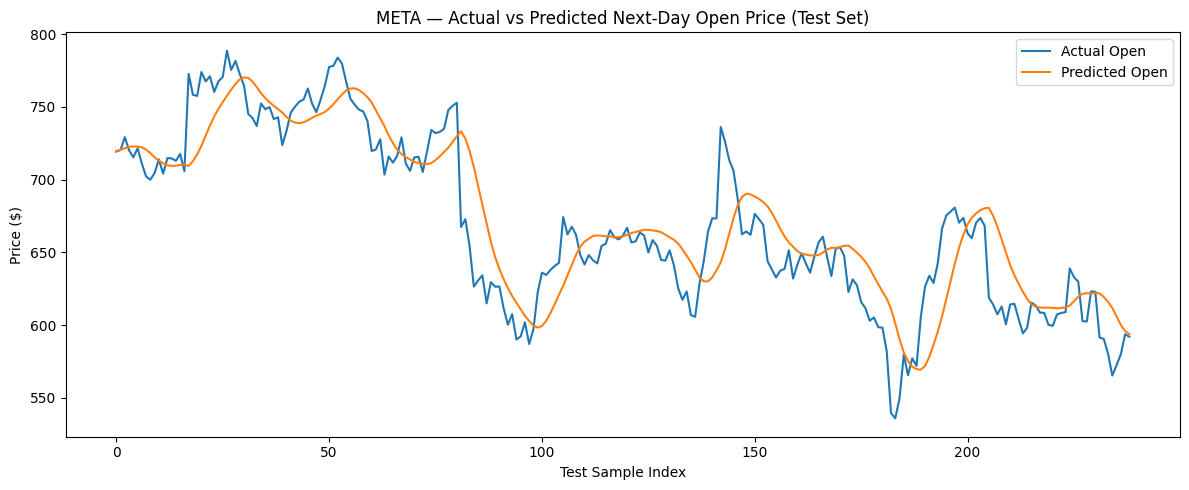

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------------------
TICKER = "META"
LOOKBACK = 60          # number of past days the LSTM sees to make one prediction
TRAIN_SPLIT = 0.8       # 80% train / 20% test
EPOCHS = 50
BATCH_SIZE = 32
USE_REAL_DATA = True    # set True when running where yfinance can reach the internet

# ---------------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------------
def load_real_data(ticker=TICKER, period="5y"):
    """Pulls real historical OHLCV data via yfinance. Requires internet access."""
    import yfinance as yf
    df = yf.download(ticker, period=period, auto_adjust=True)
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
    return df


def load_synthetic_data(last_real_close=577.22, n_days=1500, seed=42):
    """
    FOR DEMO PURPOSES ONLY (used here because this sandbox has no internet
    access to Yahoo Finance). Generates a plausible-looking OHLCV series
    using a random walk anchored at META's real last known close (~$577.22,
    June 18 2026) so the pipeline below can be demonstrated end-to-end.
    THIS IS NOT REAL MARKET DATA. Replace with load_real_data() to get
    an actual forecast.
    """
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(end=pd.Timestamp("2026-06-18"), periods=n_days)

    # simple geometric random walk with mild drift + volatility clustering
    daily_returns = rng.normal(loc=0.0006, scale=0.022, size=n_days)
    # walk backwards from the known last close so the series ends at the real value
    log_prices = np.cumsum(daily_returns[::-1])
    close = last_real_close * np.exp(-(log_prices - log_prices[0]))
    close = close[::-1]
    close[-1] = last_real_close  # anchor exactly

    open_ = close * (1 + rng.normal(0, 0.004, n_days))
    high = np.maximum(open_, close) * (1 + np.abs(rng.normal(0, 0.006, n_days)))
    low = np.minimum(open_, close) * (1 - np.abs(rng.normal(0, 0.006, n_days)))
    volume = rng.integers(12_000_000, 35_000_000, n_days)

    df = pd.DataFrame(
        {"Open": open_, "High": high, "Low": low, "Close": close, "Volume": volume},
        index=dates,
    )
    return df


if USE_REAL_DATA:
    try:
        df = load_real_data()
        print(f"Loaded {len(df)} real trading days for {TICKER}.")
    except Exception as e:
        print(f"Could not fetch real data ({e}); falling back to synthetic demo data.")
        df = load_synthetic_data()
else:
    df = load_synthetic_data()
    print(f"Using {len(df)} days of SYNTHETIC demo data anchored at last known real close.")

print(df.tail())

# ---------------------------------------------------------------
# 3. FEATURE PREP
# ---------------------------------------------------------------
# We predict next day's OPEN price using a window of past OHLCV values.
features = ["Open", "High", "Low", "Close", "Volume"]
data = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(data)

OPEN_COL_IDX = features.index("Open")


def make_sequences(scaled_data, lookback):
    X, y = [], []
    for i in range(lookback, len(scaled_data)):
        X.append(scaled_data[i - lookback:i, :])          # past `lookback` days, all features
        y.append(scaled_data[i, OPEN_COL_IDX])             # next day's Open (scaled)
    return np.array(X), np.array(y)


X, y = make_sequences(scaled, LOOKBACK)

split_idx = int(len(X) * TRAIN_SPLIT)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ---------------------------------------------------------------
# 4. BUILD LSTM MODEL
# ---------------------------------------------------------------
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)  # predicted next-day Open (scaled)
])

model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])
model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

# ---------------------------------------------------------------
# 5. TRAIN
# ---------------------------------------------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

# ---------------------------------------------------------------
# 6. EVALUATE ON TEST SET
# ---------------------------------------------------------------
def inverse_open(scaled_open_values):
    """Inverse-transform a 1D array of scaled Open values back to dollars."""
    dummy = np.zeros((len(scaled_open_values), len(features)))
    dummy[:, OPEN_COL_IDX] = scaled_open_values
    return scaler.inverse_transform(dummy)[:, OPEN_COL_IDX]


pred_test_scaled = model.predict(X_test).flatten()
pred_test = inverse_open(pred_test_scaled)
actual_test = inverse_open(y_test)

rmse = np.sqrt(np.mean((pred_test - actual_test) ** 2))
mae = np.mean(np.abs(pred_test - actual_test))
print(f"\nTest RMSE: ${rmse:.2f}")
print(f"Test MAE:  ${mae:.2f}")

# Baseline comparison: naive "tomorrow = today" predictor
naive_pred = actual_test[:-1]
naive_actual = actual_test[1:]
naive_rmse = np.sqrt(np.mean((naive_pred - naive_actual) ** 2))
print(f"Naive 'no-change' baseline RMSE: ${naive_rmse:.2f}")
print("(If the LSTM's RMSE is not meaningfully better than the naive baseline,")
print(" the model is not adding real predictive value beyond persistence.)")

# ---------------------------------------------------------------
# 7. PREDICT TOMORROW'S OPEN PRICE
# ---------------------------------------------------------------
last_window = scaled[-LOOKBACK:, :]
last_window = np.expand_dims(last_window, axis=0)  # shape (1, LOOKBACK, n_features)

next_open_scaled = model.predict(last_window).flatten()
next_open_price = inverse_open(next_open_scaled)[0]

last_known_close = df["Close"].iloc[-1]
last_known_date = df.index[-1].date()

print("\n" + "=" * 50)
print(f"Last known date in data:        {last_known_date}")
print(f"Last known Close price:         ${last_known_close}")
print(f"LSTM-predicted next-day Open:   ${next_open_price}")
print("=" * 50)

# ---------------------------------------------------------------
# 8. PLOT
# ---------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(actual_test, label="Actual Open")
plt.plot(pred_test, label="Predicted Open")
plt.title(f"{TICKER} — Actual vs Predicted Next-Day Open Price (Test Set)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.savefig("meta_lstm_prediction.png", dpi=150)
print("\nSaved chart to meta_lstm_prediction.png")